# Advanced Certification Program in Computational Data Science
## A program by IISc and TalentSprint
### Mini-Project: Complex Analytics using Pyspark

## Problem Statement

Perform complex analytics on a network intrusion dataset using Pyspark

## Learning Objectives

At the end of the mini-project, you will be able to :

* analyze the data using Pyspark
* implement RDD based operations on the data
* derive insights from the complex data

### Dataset

The dataset chosen for this mini-project is a [10% subset](https://www.kdd.org/kdd-cup/view/kdd-cup-1999/Data) of the **[KDD Cup 1999 dataset](http://kdd.ics.uci.edu/databases/kddcup99/task.html)** (Computer network intrusion detection). This is the dataset used for the Third International Knowledge Discovery and Data Mining Tools Competition. The competition task was to build a network intrusion detector, a predictive model capable of distinguishing between ``bad`` connections, called intrusions or attacks, and ``good`` normal connections. This database contains a standard set of data to be audited, which includes a wide variety of intrusions simulated in a military network environment.

## Information

Since 1999, KDD’99 has been the most widely used data set for the evaluation of anomaly detection methods. This data set is prepared by S. J. Stolfo and is built based on the data captured in DARPA’98 IDS evaluation program. DARPA’98 is about 4 gigabytes of compressed raw (binary) tcpdump data of 7 weeks of network traffic, which can be processed into about 5 million connection
records, each with about 100 bytes. KDD dataset consists of approximately 4,900,000 single connection vectors each of which contains 41 features and is labeled as either normal or an attack, with exactly one specific attack type. The simulated attacks fall into one of the following four categories:

* Denial of Service Attack (DoS): making some computing or memory resources too busy so that they deny legitimate users access to these resources.
* User to Root Attack (U2R): unauthorized access from a remote machine according to exploit machine's vulnerabilities.
* Remote to Local Attack (R2L): unauthorized access to local super user (root) privileges using system's susceptibility.
* Probing Attack: host and port scans as precursors to other attacks. An attacker scans a network to gather information or find known vulnerabilities.

KDD’99 features can be classified into three groups:

1) Basic features: this category encapsulates all the attributes that can be extracted from a TCP/IP connection. Most of these features leading to an implicit delay in detection.

2) Traffic features: this category includes features that are computed with respect to a window interval and is divided into two groups:

  * "same host" features

  * "same service" features

3) Content features: unlike most of the DoS and Probing attacks, the R2L and U2R attacks don’t have any intrusion frequent sequential patterns. This is because the DoS and Probing attacks involve many connections to some host(s) in a very short period of time, however the R2L and U2R attacks are embedded in the data portions of the packets, and normally involve only a single connection. To detect these kinds of attacks, we need some features to be able to look for suspicious behavior in the data portion, e.g., the number of failed login attempts. These features are called content features.

## Grading = 10 Points

In [1]:
#@title Install packages and Download Dataset
!pip -qq install pyspark
# Download the data
!wget -qq http://kdd.ics.uci.edu/databases/kddcup99/kddcup.data_10_percent.gz
# Download feature names
!wget -qq https://kdd.ics.uci.edu/databases/kddcup99/kddcup.names
print("Successfully Installed packages and downloaded datasets!")

     |████████████████████████████████| 281.3 MB 34 kB/s 
     |████████████████████████████████| 199 kB 58.0 MB/s 
Successfully Installed packages and downloaded datasets!


### Create Spark Session and load the data (1 point)

#### Import required packages

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql import SQLContext
from pyspark.sql.functions import *
from pyspark.mllib.stat import Statistics 
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
from operator import add

#### Create a Spark session

A Spark session is a combined entry point of a Spark application, which came into implementation from Spark 2.0 (Instead of having various contexts, everything is encapsulated in a Spark session)

In [3]:
# Start spark session
spark = SparkSession.builder.appName('networkdata').getOrCreate()
spark

#### Creating an RDD from a File

The most common way of creating an RDD is to load it from a file. Notice that Spark's textFile can handle compressed files directly.

In [4]:
# YOUR CODE HERE to access sparkContext from sparkSession instance.
sc = spark.sparkContext

Load the dataset and show the top 10 records

Hint: sparkContext.textFile()

In [5]:
filePath = "/content/kddcup.data_10_percent.gz"
rdd = sc.textFile(filePath)

In [6]:
rdd.take(1)

['0,tcp,http,SF,181,5450,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,8,8,0.00,0.00,0.00,0.00,1.00,0.00,0.00,9,9,1.00,0.00,0.11,0.00,0.00,0.00,0.00,0.00,normal.']

### RDD Basic Operations (4 points)

#### Convert the data to CSV format (list of elements).

To create a Dataframe using the RDD file, convert each row into a list by splitting with a comma (,)

Hint: `map()` and `split()`

In [7]:
rdd.saveAsTextFile('/content/kddcup_data_3.csv')

In [8]:
dataset = spark.read.csv("/content/kddcup_data_3.csv",header=False)

In [9]:
df = dataset.toDF("duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes", "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in", "num_compromised", "root_shell", "su_attempted", "num_root", "num_file_creations", "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login", "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count", "dst_host_same_srv_rate", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate", "dst_host_serror_rate", "dst_host_srv_serror_rate", "dst_host_rerror_rate", "dst_host_srv_rerror_rate","category")
df.printSchema()

root
 |-- duration: string (nullable = true)
 |-- protocol_type: string (nullable = true)
 |-- service: string (nullable = true)
 |-- flag: string (nullable = true)
 |-- src_bytes: string (nullable = true)
 |-- dst_bytes: string (nullable = true)
 |-- land: string (nullable = true)
 |-- wrong_fragment: string (nullable = true)
 |-- urgent: string (nullable = true)
 |-- hot: string (nullable = true)
 |-- num_failed_logins: string (nullable = true)
 |-- logged_in: string (nullable = true)
 |-- num_compromised: string (nullable = true)
 |-- root_shell: string (nullable = true)
 |-- su_attempted: string (nullable = true)
 |-- num_root: string (nullable = true)
 |-- num_file_creations: string (nullable = true)
 |-- num_shells: string (nullable = true)
 |-- num_access_files: string (nullable = true)
 |-- num_outbound_cmds: string (nullable = true)
 |-- is_host_login: string (nullable = true)
 |-- is_guest_login: string (nullable = true)
 |-- count: string (nullable = true)
 |-- srv_count: st

In [10]:
df.columns

['duration',
 'protocol_type',
 'service',
 'flag',
 'src_bytes',
 'dst_bytes',
 'land',
 'wrong_fragment',
 'urgent',
 'hot',
 'num_failed_logins',
 'logged_in',
 'num_compromised',
 'root_shell',
 'su_attempted',
 'num_root',
 'num_file_creations',
 'num_shells',
 'num_access_files',
 'num_outbound_cmds',
 'is_host_login',
 'is_guest_login',
 'count',
 'srv_count',
 'serror_rate',
 'srv_serror_rate',
 'rerror_rate',
 'srv_rerror_rate',
 'same_srv_rate',
 'diff_srv_rate',
 'srv_diff_host_rate',
 'dst_host_count',
 'dst_host_srv_count',
 'dst_host_same_srv_rate',
 'dst_host_diff_srv_rate',
 'dst_host_same_src_port_rate',
 'dst_host_srv_diff_host_rate',
 'dst_host_serror_rate',
 'dst_host_srv_serror_rate',
 'dst_host_rerror_rate',
 'dst_host_srv_rerror_rate',
 'category']

Count how many interactions are normal and attacked in the dataset.

Hint: apply `filter` on each row, except the rows with 'normal.', all the remaining values are attacked.

In [11]:
df.count()

494021

In [12]:
df.filter(col('category').contains('normal')).count()

97278

In [13]:
df.where(~col('category').contains('normal')).count()

396743

In [14]:
df.where(~col('category').contains('normal')).show()

+--------+-------------+-------+----+---------+---------+----+--------------+------+---+-----------------+---------+---------------+----------+------------+--------+------------------+----------+----------------+-----------------+-------------+--------------+-----+---------+-----------+---------------+-----------+---------------+-------------+-------------+------------------+--------------+------------------+----------------------+----------------------+---------------------------+---------------------------+--------------------+------------------------+--------------------+------------------------+----------------+
|duration|protocol_type|service|flag|src_bytes|dst_bytes|land|wrong_fragment|urgent|hot|num_failed_logins|logged_in|num_compromised|root_shell|su_attempted|num_root|num_file_creations|num_shells|num_access_files|num_outbound_cmds|is_host_login|is_guest_login|count|srv_count|serror_rate|srv_serror_rate|rerror_rate|srv_rerror_rate|same_srv_rate|diff_srv_rate|srv_diff_host_rat

#### Protocol and Service combinations using Cartesian product

We can compute the Cartesian product between two RDDs by using the Cartesian transformation. It returns all possible pairs of elements between two RDDs. In our case, we will use it to generate all the possible combinations between Service and Protocol in our network interactions.

First of all, isolate each collection of values in two separate RDDs. For that use `distinct` on the CSV-parsed dataset. From the dataset description, we know that protocol is the second column and service is the third.

In [15]:
rdd1 = sc.parallelize(df.select('protocol_type').distinct().collect())
rdd1

ParallelCollectionRDD[48] at readRDDFromFile at PythonRDD.scala:274

In [16]:
rdd2 = sc.parallelize(df.select('service').distinct().collect())
rdd2

ParallelCollectionRDD[56] at readRDDFromFile at PythonRDD.scala:274

Now let's do the Cartesian product

Hint: [Cartesian](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.RDD.cartesian.html#:~:text=Return%20the%20Cartesian%20product%20of,and%20b%20is%20in%20other%20.)

In [17]:
rdd1.cartesian(rdd2).collect()

[(Row(protocol_type='tcp'), Row(service='telnet')),
 (Row(protocol_type='tcp'), Row(service='ftp')),
 (Row(protocol_type='tcp'), Row(service='auth')),
 (Row(protocol_type='tcp'), Row(service='iso_tsap')),
 (Row(protocol_type='tcp'), Row(service='systat')),
 (Row(protocol_type='tcp'), Row(service='name')),
 (Row(protocol_type='tcp'), Row(service='sql_net')),
 (Row(protocol_type='tcp'), Row(service='ntp_u')),
 (Row(protocol_type='tcp'), Row(service='X11')),
 (Row(protocol_type='tcp'), Row(service='pop_3')),
 (Row(protocol_type='tcp'), Row(service='ldap')),
 (Row(protocol_type='tcp'), Row(service='discard')),
 (Row(protocol_type='tcp'), Row(service='tftp_u')),
 (Row(protocol_type='tcp'), Row(service='Z39_50')),
 (Row(protocol_type='tcp'), Row(service='daytime')),
 (Row(protocol_type='tcp'), Row(service='domain_u')),
 (Row(protocol_type='tcp'), Row(service='login')),
 (Row(protocol_type='tcp'), Row(service='smtp')),
 (Row(protocol_type='tcp'), Row(service='mtp')),
 (Row(protocol_type='tcp'

#### Inspecting interaction duration

select the total duration of interactions for normal and attack intrusion types.
* Use the above filtered normal and attacked data and convert the duration column to integer type using `map()`
* get the sum of duration by applying `reduce` on both the data using add operator
* find the mean of duration by dividing the sum with count

Hint: [reduce()](https://spark.apache.org/docs/3.1.1/api/python/reference/api/pyspark.RDD.reduce.html)

In [18]:
from pyspark.sql.types import IntegerType
df = df.withColumn("duration", df["duration"].cast(IntegerType()))

In [19]:
df.filter(col('category').contains('normal')).agg(avg('duration')).show()

+------------------+
|     avg(duration)|
+------------------+
|216.65732231336992|
+------------------+



In [20]:
df.where(~col('category').contains('normal')).agg(avg('duration')).show()

+-----------------+
|    avg(duration)|
+-----------------+
|6.620890601724542|
+-----------------+



#### Data aggregation with key/value pair RDDs

We can use all the transformations and actions available for normal RDDs with key/value pair RDDs. We just need to make the functions work with pair elements.

* create a key/value pair of intrusion type and duration
* calculate the total duration of each intrusion type using `reduceByKey()`

In [21]:
df_intrusion = df.where(~col('category').contains('normal'))

In [22]:
rdd4 = sc.parallelize(df_intrusion.select('category','duration').collect())
rdd4

ParallelCollectionRDD[76] at readRDDFromFile at PythonRDD.scala:274

In [23]:
# Apply reduceByKey() operation on Rdd
rdd_reduced = rdd4.reduceByKey(lambda x, y: x + y)

# Iterate over the result and print the output
for num in rdd_reduced.collect():
  print("Key {} has {} Duration".format(num[0], num[1]))

Key loadmodule. has 326 Duration
Key neptune. has 0 Duration
Key guess_passwd. has 144 Duration
Key pod. has 0 Duration
Key teardrop. has 0 Duration
Key portsweep. has 1991911 Duration
Key warezmaster. has 301 Duration
Key warezclient. has 627563 Duration
Key spy. has 636 Duration
Key rootkit. has 1008 Duration
Key buffer_overflow. has 2751 Duration
Key perl. has 124 Duration
Key smurf. has 0 Duration
Key ipsweep. has 43 Duration
Key land. has 0 Duration
Key ftp_write. has 259 Duration
Key back. has 284 Duration
Key imap. has 72 Duration
Key satan. has 64 Duration
Key phf. has 18 Duration
Key nmap. has 0 Duration
Key multihop. has 1288 Duration


### Create a DataFrame with the header as features (2 points)

* Read the features (*kddcup.names*) and preprocess.

    Hints:
    - Each feature description appears row-wise in *kddcup.names*
    - The first row consists of distinct values of intrusion_types
    - Add or move the *intrusion_types* column name to the last, to align with the data.
    - Each feature is represented as *feature_name*: *type*, remove *type* after colon (:)

* Create a dataframe with the data and headers as preprocessed feature names

In [94]:
df3 = dataset.toDF("duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes", "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in", "num_compromised", "root_shell", "su_attempted", "num_root", "num_file_creations", "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login", "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count", "dst_host_same_srv_rate", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate", "dst_host_serror_rate", "dst_host_srv_serror_rate", "dst_host_rerror_rate", "dst_host_srv_rerror_rate","category")
df.printSchema()

root
 |-- duration: integer (nullable = true)
 |-- protocol_type: string (nullable = true)
 |-- service: string (nullable = true)
 |-- flag: string (nullable = true)
 |-- src_bytes: string (nullable = true)
 |-- dst_bytes: string (nullable = true)
 |-- land: string (nullable = true)
 |-- wrong_fragment: string (nullable = true)
 |-- urgent: string (nullable = true)
 |-- hot: string (nullable = true)
 |-- num_failed_logins: string (nullable = true)
 |-- logged_in: string (nullable = true)
 |-- num_compromised: string (nullable = true)
 |-- root_shell: string (nullable = true)
 |-- su_attempted: string (nullable = true)
 |-- num_root: string (nullable = true)
 |-- num_file_creations: string (nullable = true)
 |-- num_shells: string (nullable = true)
 |-- num_access_files: string (nullable = true)
 |-- num_outbound_cmds: string (nullable = true)
 |-- is_host_login: string (nullable = true)
 |-- is_guest_login: string (nullable = true)
 |-- count: string (nullable = true)
 |-- srv_count: s

#### What is the count of each protocol type?

Hint: apply `groupby` on protocol_type and count the records

In [26]:
df.select('protocol_type').groupby('protocol_type').agg(count('protocol_type')).show()

+-------------+--------------------+
|protocol_type|count(protocol_type)|
+-------------+--------------------+
|          tcp|              190065|
|          udp|               20354|
|         icmp|              283602|
+-------------+--------------------+



#### Register the DataFrame as a temporary table and extract the data using queries

Hint: [registerTempTable](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.sql.DataFrame.registerTempTable.html)

In [27]:
df.registerTempTable("networkData")
df_intrusion.registerTempTable("intrusion_data")

/usr/local/lib/python3.7/dist-packages/pyspark/sql/dataframe.py:229: FutureWarning: Deprecated in 2.0, use createOrReplaceTempView instead.
  warnings.warn("Deprecated in 2.0, use createOrReplaceTempView instead.", FutureWarning)


In [28]:
result = spark.sql('select * from networkData limit 10')
result.show(10)

+--------+-------------+-------+----+---------+---------+----+--------------+------+---+-----------------+---------+---------------+----------+------------+--------+------------------+----------+----------------+-----------------+-------------+--------------+-----+---------+-----------+---------------+-----------+---------------+-------------+-------------+------------------+--------------+------------------+----------------------+----------------------+---------------------------+---------------------------+--------------------+------------------------+--------------------+------------------------+--------+
|duration|protocol_type|service|flag|src_bytes|dst_bytes|land|wrong_fragment|urgent|hot|num_failed_logins|logged_in|num_compromised|root_shell|su_attempted|num_root|num_file_creations|num_shells|num_access_files|num_outbound_cmds|is_host_login|is_guest_login|count|srv_count|serror_rate|srv_serror_rate|rerror_rate|srv_rerror_rate|same_srv_rate|diff_srv_rate|srv_diff_host_rate|dst_ho

* query to extract the label and their frequencies
 
 Hint: `SQLContext.sql(query)`

In [29]:
result = spark.sql('select count(distinct(networkData.category)) from networkData')
result.show()

+------------------------+
|count(DISTINCT category)|
+------------------------+
|                      23|
+------------------------+



In [30]:
result = spark.sql('select category, count(*) from networkData group by category')
result.show(50)

+----------------+--------+
|        category|count(1)|
+----------------+--------+
|    warezmaster.|      20|
|          smurf.|  280790|
|            pod.|     264|
|           imap.|      12|
|           nmap.|     231|
|   guess_passwd.|      53|
|        ipsweep.|    1247|
|      portsweep.|    1040|
|          satan.|    1589|
|           land.|      21|
|     loadmodule.|       9|
|      ftp_write.|       8|
|buffer_overflow.|      30|
|        rootkit.|      10|
|    warezclient.|    1020|
|       teardrop.|     979|
|           perl.|       3|
|            phf.|       4|
|       multihop.|       7|
|        neptune.|  107201|
|           back.|    2203|
|            spy.|       2|
|         normal.|   97278|
+----------------+--------+



* select the distinct protocol types with their count of transactions which are not normal

In [31]:
result = spark.sql('select protocol_type, count(*) from intrusion_data group by protocol_type')
result.show()

+-------------+--------+
|protocol_type|count(1)|
+-------------+--------+
|          tcp|  113252|
|          udp|    1177|
|         icmp|  282314|
+-------------+--------+



* select count of transactions in each protocol type that lasts more than 1 second (duration > 1000), with no data transfer from destination (dst_bytes == 0)

In [32]:
result = spark.sql('select protocol_type, count(*) from networkData where duration > 1000 and dst_bytes = 0 group by protocol_type')
result.show()

+-------------+--------+
|protocol_type|count(1)|
+-------------+--------+
|          tcp|     139|
+-------------+--------+



### Find the highly correlated columns (2 points)

* identify the columns which are not integer type and remove those columns
* apply correlation function on the data (Hint: `Statistics.corr()`)
* collect the names of the columns on which correlation is applied
* create a dataframe with correlation matrix with index and columns as names
* get the highly correlated features by considering a correlation value greater than 0.8

    Hint: `np.triu()` , `pd.mask()`

In [41]:
# Dropping non integer columns
# eliminating names of columns having string type

df_numeric = df.drop("protocol_type","service","flag","category")

In [ ]:
df_numeric.schema

In [43]:
df_numeric.select(*(col(c).cast("float").alias(c) for c in df_numeric.columns))

DataFrame[duration: float, src_bytes: float, dst_bytes: float, land: float, wrong_fragment: float, urgent: float, hot: float, num_failed_logins: float, logged_in: float, num_compromised: float, root_shell: float, su_attempted: float, num_root: float, num_file_creations: float, num_shells: float, num_access_files: float, num_outbound_cmds: float, is_host_login: float, is_guest_login: float, count: float, srv_count: float, serror_rate: float, srv_serror_rate: float, rerror_rate: float, srv_rerror_rate: float, same_srv_rate: float, diff_srv_rate: float, srv_diff_host_rate: float, dst_host_count: float, dst_host_srv_count: float, dst_host_same_srv_rate: float, dst_host_diff_srv_rate: float, dst_host_same_src_port_rate: float, dst_host_srv_diff_host_rate: float, dst_host_serror_rate: float, dst_host_srv_serror_rate: float, dst_host_rerror_rate: float, dst_host_srv_rerror_rate: float]

In [44]:
# creating a dataframe with correlation matrix
pd_df = df_numeric.toPandas()

In [ ]:
pd_df

In [ ]:
#  fill the null values with 0
pd_df.fillna(0)

In [52]:
pd_df

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
0,0,181,5450,0,0,0,0,0,1,0,...,9,9,1.00,0.00,0.11,0.00,0.00,0.00,0.00,0.00
1,0,239,486,0,0,0,0,0,1,0,...,19,19,1.00,0.00,0.05,0.00,0.00,0.00,0.00,0.00
2,0,235,1337,0,0,0,0,0,1,0,...,29,29,1.00,0.00,0.03,0.00,0.00,0.00,0.00,0.00
3,0,219,1337,0,0,0,0,0,1,0,...,39,39,1.00,0.00,0.03,0.00,0.00,0.00,0.00,0.00
4,0,217,2032,0,0,0,0,0,1,0,...,49,49,1.00,0.00,0.02,0.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494016,0,310,1881,0,0,0,0,0,1,0,...,86,255,1.00,0.00,0.01,0.05,0.00,0.01,0.00,0.00
494017,0,282,2286,0,0,0,0,0,1,0,...,6,255,1.00,0.00,0.17,0.05,0.00,0.01,0.00,0.00
494018,0,203,1200,0,0,0,0,0,1,0,...,16,255,1.00,0.00,0.06,0.05,0.06,0.01,0.00,0.00
494019,0,291,1200,0,0,0,0,0,1,0,...,26,255,1.00,0.00,0.04,0.05,0.04,0.01,0.00,0.00


In [55]:
pd_df=pd_df.apply(lambda x: pd.to_numeric(x, errors='ignore'))

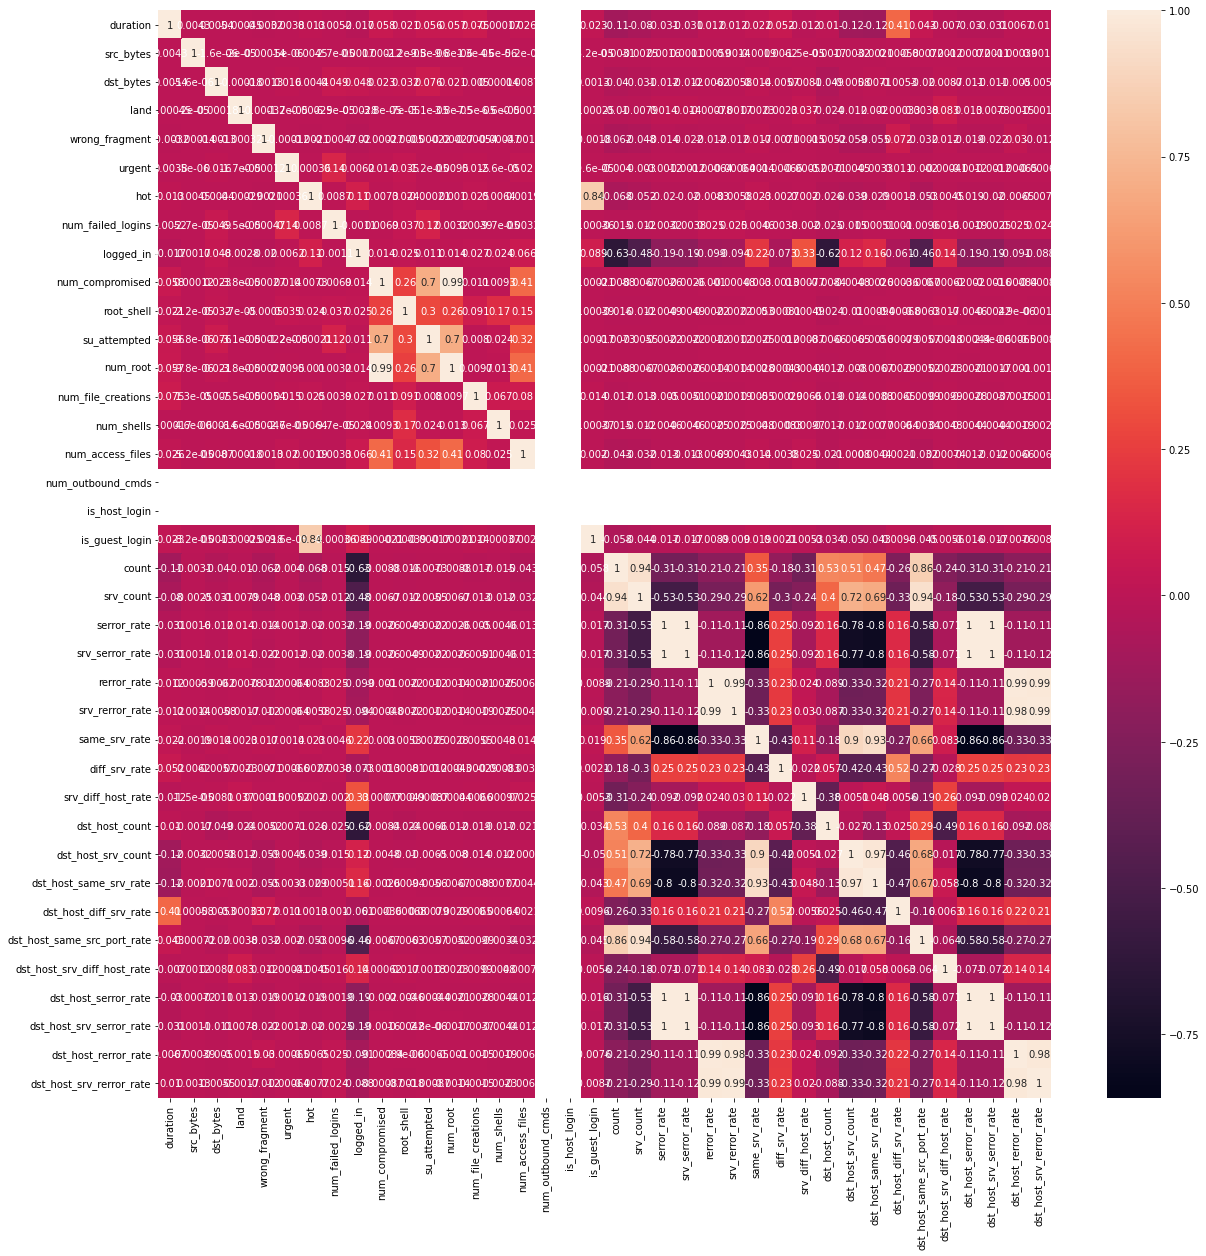

In [58]:
plt.figure(figsize = (20,20))
sns.heatmap(pd_df.corr(),annot=True)

In [61]:
# Finding features with correlation value more than specified threshold value (bar=0.9)
# https://stackoverflow.com/questions/17778394/list-highest-correlation-pairs-from-a-large-correlation-matrix-in-pandas
def get_redundant_pairs(df):
    '''Get diagonal and lower triangular pairs of correlation matrix'''
    pairs_to_drop = set()
    cols = df.columns
    for i in range(0, df.shape[1]):
        for j in range(0, i+1):
            pairs_to_drop.add((cols[i], cols[j]))
    return pairs_to_drop

def get_top_abs_correlations(df, n=5):
    au_corr = df.corr().abs().unstack()
    labels_to_drop = get_redundant_pairs(df)
    au_corr = au_corr.drop(labels=labels_to_drop).sort_values(ascending=False)
    return au_corr[0:n]

print("Top Absolute Correlations")
print(get_top_abs_correlations(pd_df, 17))

Top Absolute Correlations
srv_serror_rate       dst_host_srv_serror_rate       0.999304
serror_rate           dst_host_serror_rate           0.998673
                      srv_serror_rate                0.998362
dst_host_serror_rate  dst_host_srv_serror_rate       0.998156
serror_rate           dst_host_srv_serror_rate       0.997849
srv_serror_rate       dst_host_serror_rate           0.997835
rerror_rate           srv_rerror_rate                0.994731
num_compromised       num_root                       0.993828
rerror_rate           dst_host_rerror_rate           0.986995
srv_rerror_rate       dst_host_srv_rerror_rate       0.986571
rerror_rate           dst_host_srv_rerror_rate       0.985200
dst_host_rerror_rate  dst_host_srv_rerror_rate       0.984804
srv_rerror_rate       dst_host_rerror_rate           0.982166
dst_host_srv_count    dst_host_same_srv_rate         0.973685
srv_count             dst_host_same_src_port_rate    0.944926
count                 srv_count             

### Analysis report (1 points)

* Find the ratio of attacked transactions vs normal transactions

    Hint: encode instrusion_type column by replacing normal with 1 and all other with 0

* Describe the statistics of attacked and normal transactions
    
    Hint: Min, Max, Mean
    
* Select any two features that influence the intrusion_type and visualize the scatter plot to see the separation of normal and attacked

In [62]:
#Find the ratio of attacked transactions vs normal transactions
df.filter(col('category').contains('normal')).count()

97278

In [63]:
df.where(~col('category').contains('normal')).count()

396743

In [64]:
# Ratio
ratio = 396743/97278
ratio #4.0784452805361955

4.0784452805361955

In [65]:
# Mean Duration of Intrusion
df.where(~col('category').contains('normal')).agg(avg('duration')).show()

+-----------------+
|    avg(duration)|
+-----------------+
|6.620890601724542|
+-----------------+



In [67]:
df.where(~col('category').contains('normal')).agg(max('duration')).show()

+-------------+
|max(duration)|
+-------------+
|        42448|
+-------------+



In [68]:
df.where(~col('category').contains('normal')).agg(min('duration')).show()

+-------------+
|min(duration)|
+-------------+
|            0|
+-------------+



In [66]:
# Mean Duration of Normal
df.filter(col('category').contains('normal')).agg(avg('duration')).show()

+------------------+
|     avg(duration)|
+------------------+
|216.65732231336992|
+------------------+



In [69]:
df.filter(col('category').contains('normal')).agg(max('duration')).show()

+-------------+
|max(duration)|
+-------------+
|        58329|
+-------------+



In [70]:
df.filter(col('category').contains('normal')).agg(min('duration')).show()

+-------------+
|min(duration)|
+-------------+
|            0|
+-------------+



In [82]:
# Analysis using serror_rate and rerror_rate as the features indicating intrusion_type. Creating scatter plot for normal and intrusion traffic

df_analysis = df[['serror_rate','rerror_rate','category']]

In [83]:
pd_df_analysis = df_analysis.toPandas()

In [87]:
pd_df_analysis.serror_rate = pd_df_analysis.serror_rate.astype(float)
pd_df_analysis.rerror_rate = pd_df_analysis.rerror_rate.astype(float)


In [88]:
pd_df_analysis.dtypes

serror_rate    float64
rerror_rate    float64
category        object
dtype: object

In [90]:
pd_df_analysis.tail()

,serror_rate,rerror_rate,category
494016,0.00,0.0,normal.
494017,0.00,0.0,normal.
494018,0.17,0.0,normal.
494019,0.00,0.0,normal.
494020,0.00,0.0,normal.


In [91]:
pd_df_analysis.category = pd_df_analysis.category.apply(lambda x: 'intrusion' if 'normal' not in x else x)

In [92]:
pd_df_analysis.category.value_counts()

intrusion    396743
normal.       97278
Name: category, dtype: int64

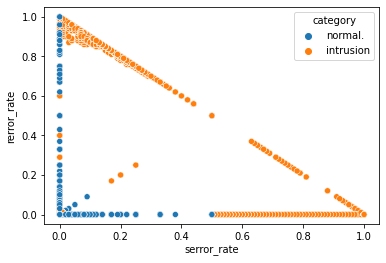

In [93]:
sns.scatterplot(data=pd_df_analysis, x="serror_rate", y="rerror_rate", hue="category")